# CRNN OCR

Membangun model **CRNN (Convolutional Recurrent Neural Network)** untuk membaca teks pada label nutrisi kemasan makanan Indonesia.


## 1. Import Library


In [ ]:
# Library utama
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import cv2
from PIL import Image

# Drive
from google.colab import drive
drive.mount('/content/drive')

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Augmentasi
import albumentations as A

# Utilitas
from sklearn.model_selection import train_test_split
from collections import Counter
import datetime
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


## 2. Konfigurasi & Hyperparameter

Kita definisikan semua konfigurasi di satu tempat supaya mudah diubah.

In [ ]:
# KONFIGURASI
import os
import datetime

IMG_HEIGHT = 64        # tinggi gambar input
IMG_WIDTH = 480        # LEBAR DITAMBAH LAGI agar angka/digit terlihat lebih terpisah dan jelas
BATCH_SIZE = 16        # ukuran batch
EPOCHS = 200           # jumlah epoch training
LEARNING_RATE = 0.0002 # learning rate sangat halus untuk full fine-tuning
PATIENCE = 20          # early stopping patience

# Path dataset
BASE_DIR = '/content/drive/MyDrive/Colab_Notebooks/CRNN'
TEST_DIR = BASE_DIR + "/test"
VALID_CSV = BASE_DIR + "/valid/valid.csv"

# Direktori output
MODEL_DIR = "saved_model"
LOG_DIR = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print("Konfigurasi selesai!")
print(f"Input shape: ({IMG_HEIGHT}, {IMG_WIDTH}, 3)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

Konfigurasi selesai!
Input shape: (64, 480, 3)
Batch size: 16
Epochs: 200


## 3. Load & Eksplorasi Data (EDA)

Mari kita lihat struktur dataset yang kita punya.

In [ ]:
# Load label dari CSV
df = pd.read_csv(VALID_CSV)
print(f"Total data: {len(df)} gambar")
print(f"\nKolom: {list(df.columns)}")
print(f"\n5 data pertama:")
df.head(10)

Total data: 420 gambar

Kolom: ['file_name', 'text', 'quality']

5 data pertama:


,file_name,text,quality
0,calories_001.png,Energi total 140 Kkal,blur
1,calories_002.png,Energi Total 180 kkal,clear
2,calories_003.png,Energi Total / Calories 100 kkal,overlap
3,calories_004.png,Energi Total 110 kkal,clear
4,calories_005.png,Energi Total/Total Energy 120 kkal,clear
5,calories_006.png,Energi Total/Total Energy 120 kkal,overlap
6,calories_007.png,Energi Total/Total Energy 150 kkal/kcal,overlap
7,calories_008.png,Energi Total 160 kkal Total Energy 160 kcal,clear
8,calories_009.png,Energi total 30 kkal,clear
9,calories_010.png,Energi total 120 kkal,clear


In [ ]:
# Cek kategori dari nama file
df['category'] = df['file_name'].apply(lambda x: x.split('_')[0])

print("Distribusi kategori:")
print(df['category'].value_counts())
print(f"\nDistribusi kualitas gambar:")
print(df['quality'].value_counts())

Distribusi kategori:
category
calories    84
carbs       84
fat         84
sodium      84
sugar       84
Name: count, dtype: int64

Distribusi kualitas gambar:
quality
clear      180
overlap    180
blur        37
glare       23
Name: count, dtype: int64


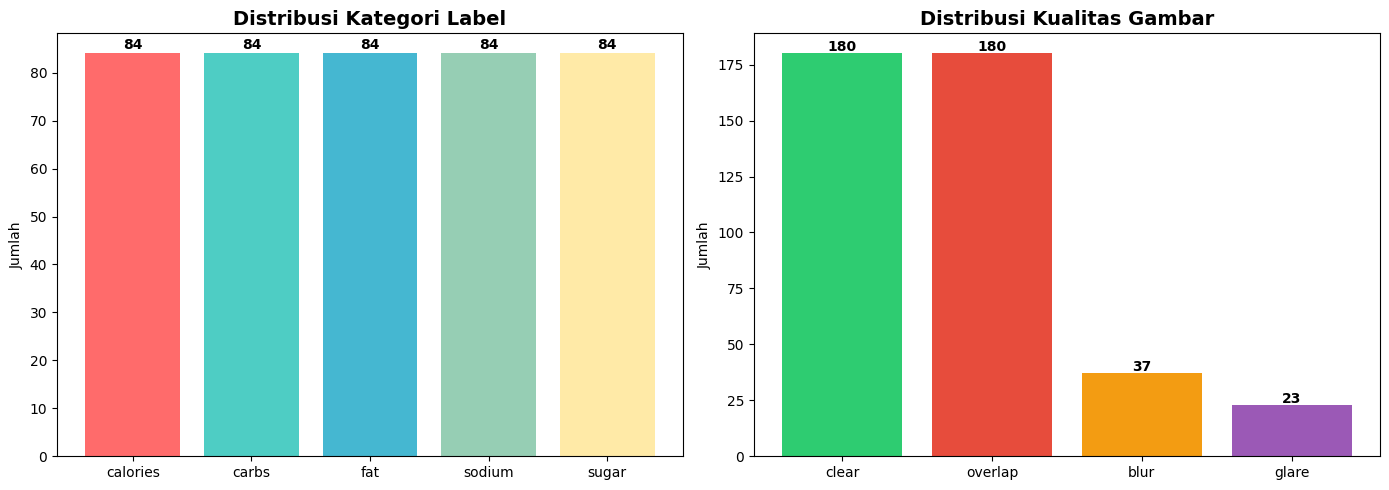

In [ ]:
# Visualisasi distribusi kategori dan kualitas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi kategori
cat_counts = df['category'].value_counts()
colors_cat = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
axes[0].bar(cat_counts.index, cat_counts.values, color=colors_cat)
axes[0].set_title('Distribusi Kategori Label', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')

# Distribusi kualitas
qual_counts = df['quality'].value_counts()
colors_qual = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
axes[1].bar(qual_counts.index, qual_counts.values, color=colors_qual[:len(qual_counts)])
axes[1].set_title('Distribusi Kualitas Gambar', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Jumlah')
for i, v in enumerate(qual_counts.values):
    axes[1].text(i, v+1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

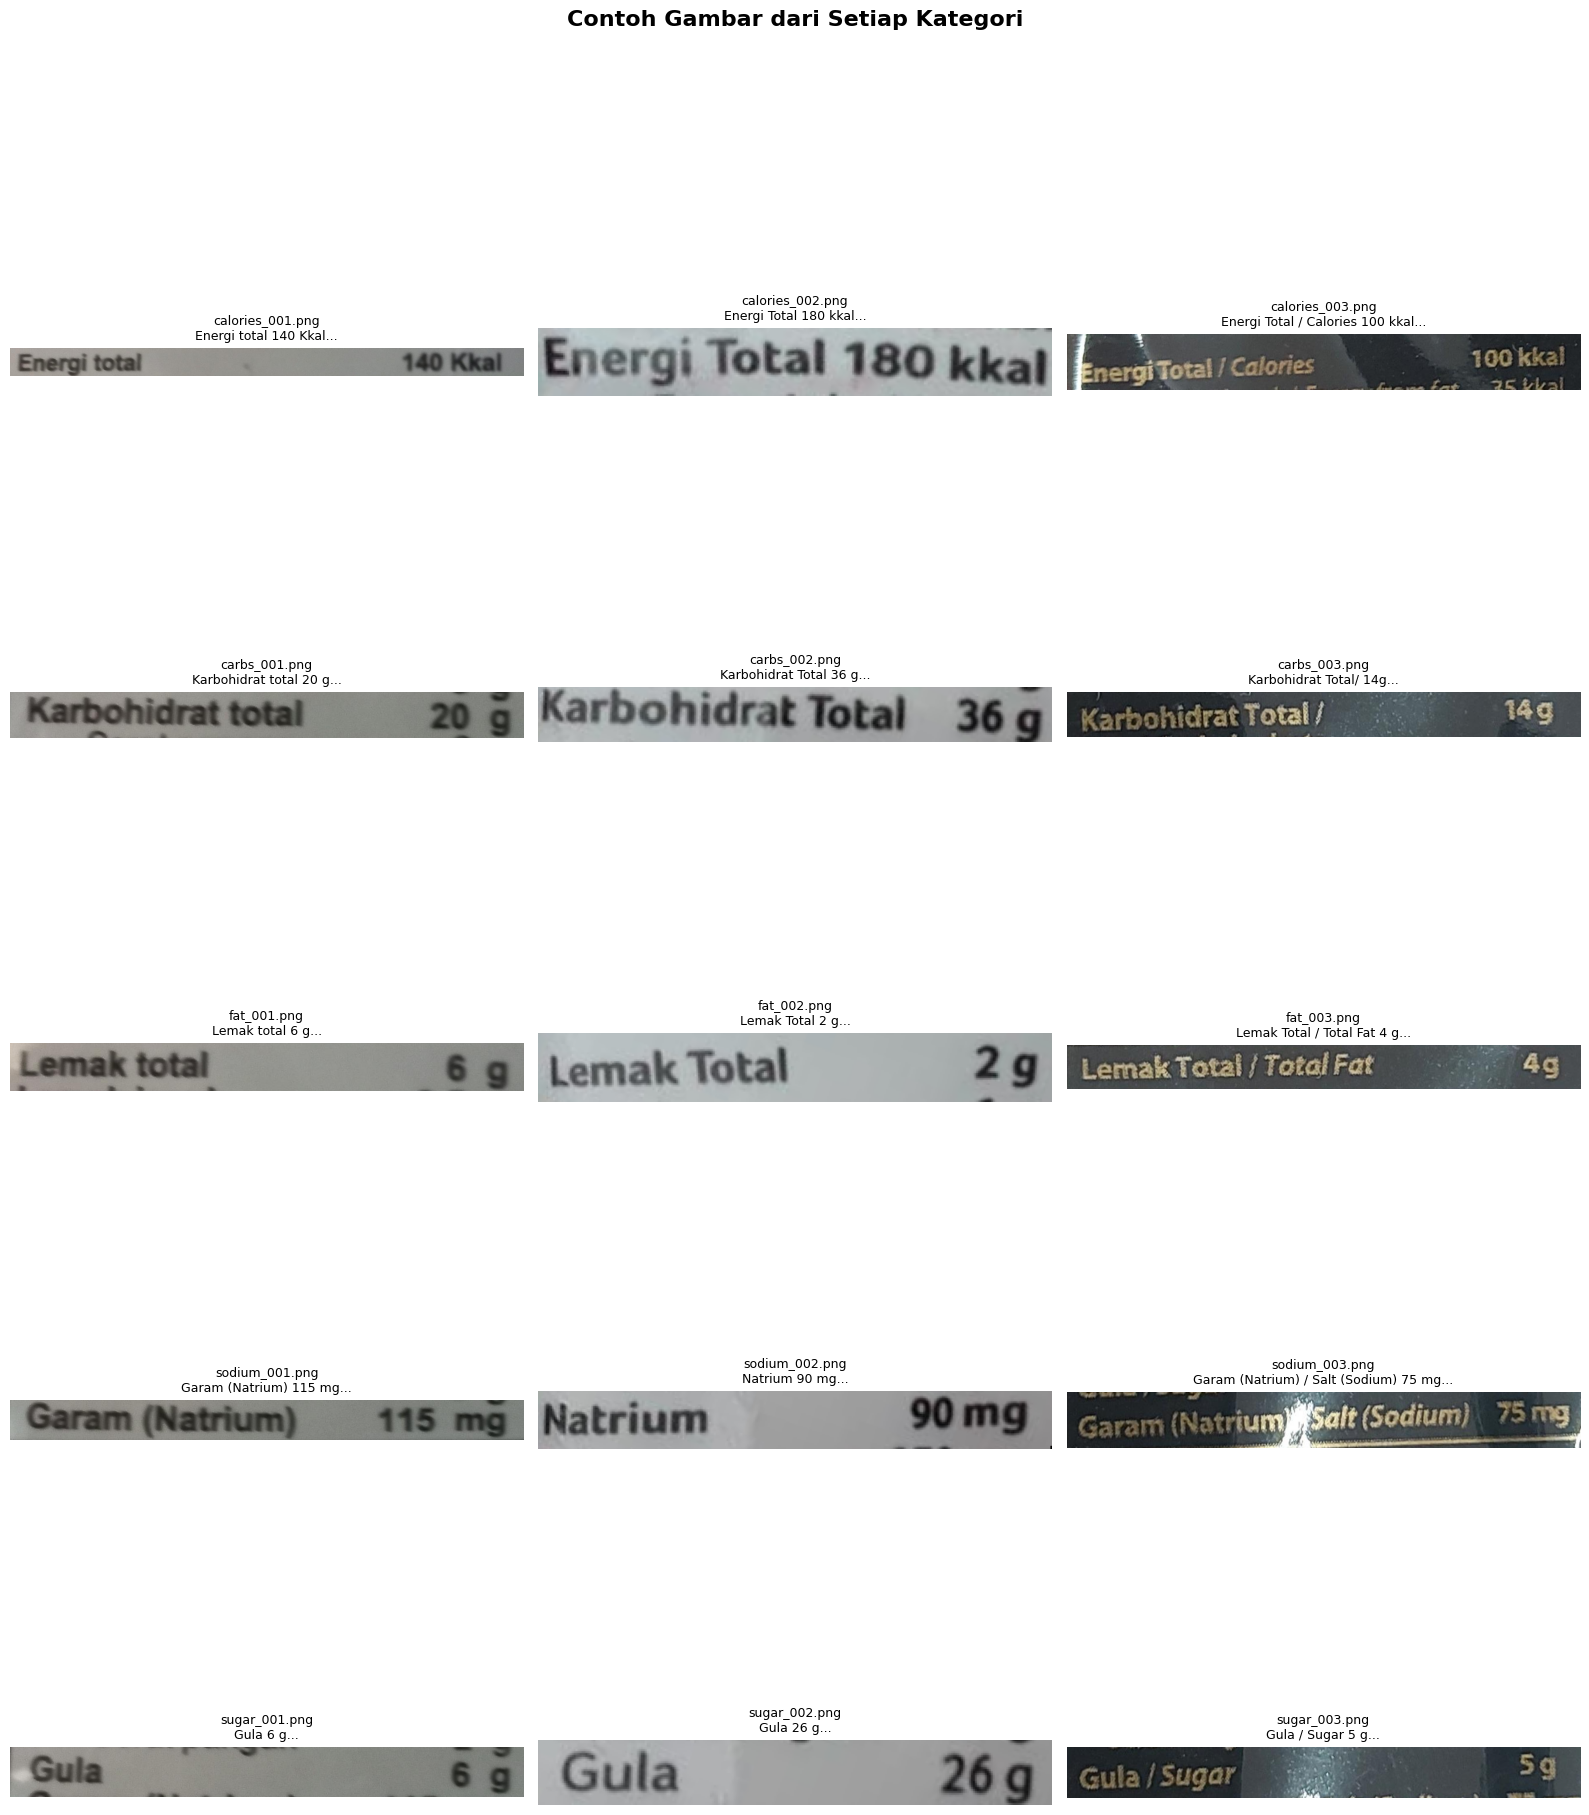

In [ ]:
# Tampilkan contoh gambar dari setiap kategori
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
categories = df['category'].unique()

for i, cat in enumerate(categories):
    cat_df = df[df['category'] == cat].head(3)
    for j, (_, row) in enumerate(cat_df.iterrows()):
        img_path = os.path.join(TEST_DIR, row['file_name'])
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i][j].imshow(img)
            axes[i][j].set_title(f"{row['file_name']}\n{row['text'][:40]}...", fontsize=9)
        axes[i][j].axis('off')

plt.suptitle('Contoh Gambar dari Setiap Kategori', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

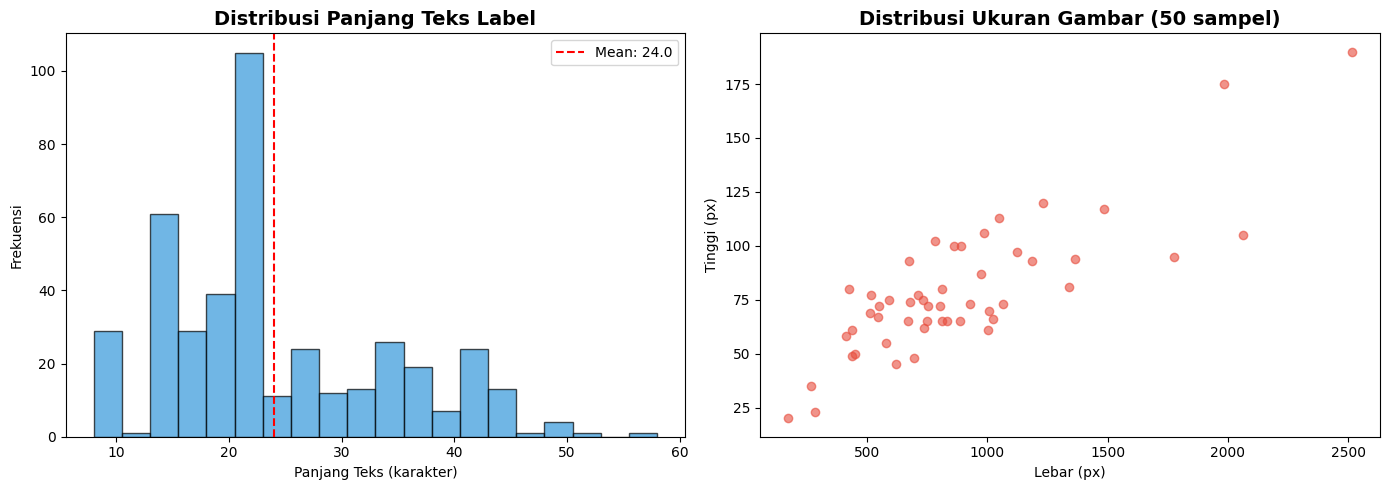

Panjang teks - Min: 8, Max: 58, Mean: 24.0
Karakter unik dalam dataset: 60 karakter


In [ ]:
# Analisis panjang teks label
df['text_length'] = df['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram panjang teks
axes[0].hist(df['text_length'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribusi Panjang Teks Label', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Panjang Teks (karakter)')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['text_length'].mean():.1f}")
axes[0].legend()

# Analisis ukuran gambar
widths, heights = [], []
for fname in df['file_name'].values[:50]:
    img = cv2.imread(os.path.join(TEST_DIR, fname))
    if img is not None:
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

axes[1].scatter(widths, heights, alpha=0.6, color='#e74c3c')
axes[1].set_title('Distribusi Ukuran Gambar (50 sampel)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lebar (px)')
axes[1].set_ylabel('Tinggi (px)')

plt.tight_layout()
plt.show()

print(f"Panjang teks - Min: {df['text_length'].min()}, Max: {df['text_length'].max()}, Mean: {df['text_length'].mean():.1f}")
print(f"Karakter unik dalam dataset: {len(set(''.join(df['text'].values)))} karakter")

## 4. Preprocessing Data

Sekarang kita siapkan data untuk training. Langkah-langkah:
1. Mapping karakter
2. Resize & normalisasi gambar
3. Encode label teks menjadi angka
4. Split data train/validation

In [ ]:
# Buat vocabulary dari semua karakter yang ada di label
all_texts = df['text'].values
all_chars = set()
for text in all_texts:
    all_chars.update(list(text))

# Urutkan karakter dan buat mapping
vocab = sorted(list(all_chars))
vocab.insert(0, '[blank]')  # CTC blank token di index 0

# Mapping karakter ke angka dan sebaliknya
char_to_num = {char: idx for idx, char in enumerate(vocab)}
num_to_char = {idx: char for idx, char in enumerate(vocab)}

NUM_CLASSES = len(vocab)  # jumlah kelas (karakter unik + blank)
MAX_LABEL_LENGTH = max(len(t) for t in all_texts) + 2  # panjang label maksimum + buffer

print(f"Jumlah karakter unik (termasuk blank): {NUM_CLASSES}")
print(f"Panjang label maksimum: {MAX_LABEL_LENGTH}")
print(f"\nVocabulary:")
print(vocab)

Jumlah karakter unik (termasuk blank): 61
Panjang label maksimum: 60

Vocabulary:
['[blank]', ' ', '%', '(', ')', ',', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', 'C', 'E', 'F', 'G', 'K', 'L', 'N', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'r', 's', 't', 'u', 'y', '…', '化', '卡', '合', '水', '物', '碳', '糖', '總', '肪', '脂', '路', '里', '鈉']


In [ ]:
# Fungsi untuk memproses gambar
def preprocess_image(image_path, target_h=IMG_HEIGHT, target_w=IMG_WIDTH):
    """
    Baca gambar, resize, dan normalisasi.
    Kita pakai padding supaya aspect ratio tetap terjaga.
    """
    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        # Kalau gagal baca, return gambar kosong
        return np.zeros((target_h, target_w, 3), dtype=np.float32)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize dengan menjaga aspect ratio
    h, w = img.shape[:2]
    ratio = min(target_w / w, target_h / h)
    new_w = int(w * ratio)
    new_h = int(h * ratio)
    img = cv2.resize(img, (new_w, new_h))

    # Padding supaya ukuran jadi seragam
    padded = np.ones((target_h, target_w, 3), dtype=np.uint8) * 255  # padding putih
    y_offset = (target_h - new_h) // 2
    x_offset = 0  # rata kiri
    padded[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img

    # Normalisasi ke range [0, 1]
    padded = padded.astype(np.float32) / 255.0

    return padded

# Fungsi untuk encode teks menjadi angka
def encode_label(text):
    """Konversi teks ke sequence angka"""
    encoded = [char_to_num[c] for c in text if c in char_to_num]
    return encoded

# Fungsi untuk decode angka menjadi teks
def decode_label(encoded):
    """Konversi sequence angka ke teks"""
    decoded = [num_to_char.get(idx, '') for idx in encoded if idx != 0]  # skip blank
    return ''.join(decoded)

# Test fungsi preprocessing
test_img = preprocess_image(os.path.join(TEST_DIR, df['file_name'].iloc[0]))
test_enc = encode_label(df['text'].iloc[0])
test_dec = decode_label(test_enc)

print(f"Shape gambar setelah preprocess: {test_img.shape}")
print(f"Teks asli: '{df['text'].iloc[0]}'")
print(f"Encoded: {test_enc}")
print(f"Decoded kembali: '{test_dec}'")

Shape gambar setelah preprocess: (64, 480, 3)
Teks asli: 'Energi total 140 Kkal'
Encoded: [20, 40, 32, 42, 34, 36, 1, 44, 41, 44, 28, 38, 1, 9, 12, 8, 1, 23, 37, 28, 38]
Decoded kembali: 'Energi total 140 Kkal'


In [ ]:
# Proses semua data
print("Memproses semua gambar...")

images = []
labels = []
label_lengths = []
valid_indices = []

for idx, row in df.iterrows():
    img_path = os.path.join(TEST_DIR, row['file_name'])

    # Preprocess gambar
    img = preprocess_image(img_path)

    # Encode label
    label = encode_label(row['text'])

    if len(label) > 0:  # pastikan label valid
        images.append(img)
        labels.append(label)
        label_lengths.append(len(label))
        valid_indices.append(idx)

print(f"Total data valid: {len(images)}")
print(f"Panjang label - Min: {min(label_lengths)}, Max: {max(label_lengths)}")

Memproses semua gambar...
Total data valid: 420
Panjang label - Min: 8, Max: 58


In [ ]:
# Padding label supaya panjangnya seragam
padded_labels = np.zeros((len(labels), MAX_LABEL_LENGTH), dtype=np.int32)
for i, label in enumerate(labels):
    padded_labels[i, :len(label)] = label

images = np.array(images, dtype=np.float32)
label_lengths = np.array(label_lengths, dtype=np.int32)

print(f"Shape images: {images.shape}")
print(f"Shape labels: {padded_labels.shape}")

# Split data: 80% train, 20% validation
X_train, X_val, y_train, y_val, len_train, len_val = train_test_split(
    images, padded_labels, label_lengths,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain: {X_train.shape[0]} gambar")
print(f"Validation: {X_val.shape[0]} gambar")

Shape images: (420, 64, 480, 3)
Shape labels: (420, 60)

Train: 336 gambar
Validation: 84 gambar


## 5. Data Augmentation

Untuk menambah variasi data training, menggunakan augmentasi gambar.
Penting karena dataset tidak terlalu banyak.

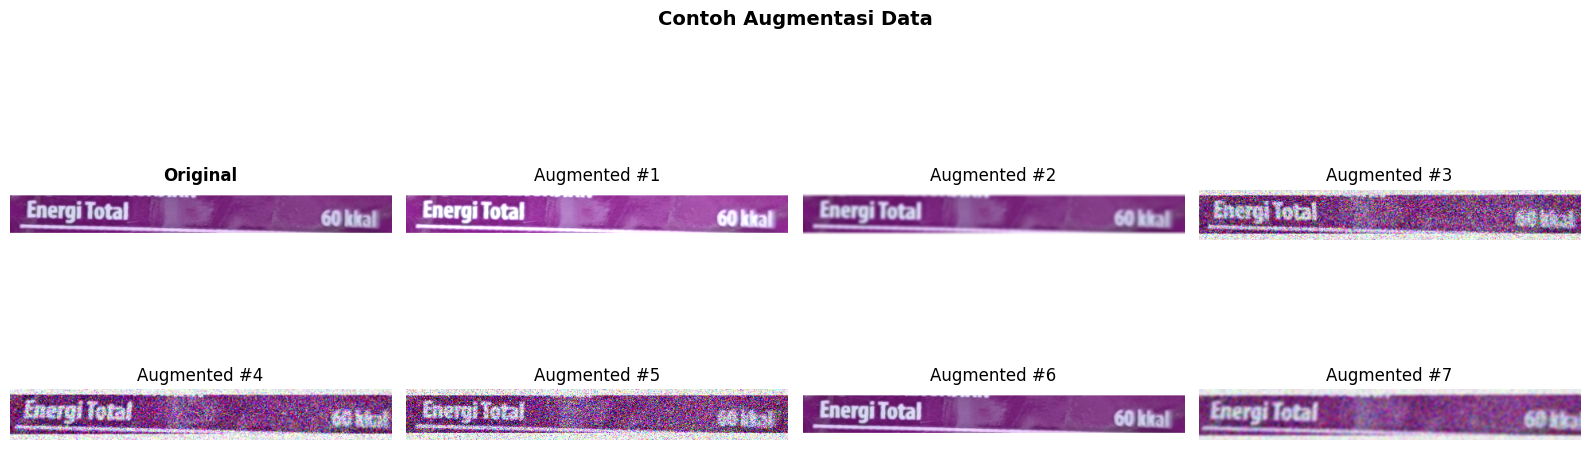

In [ ]:
# Definisikan augmentasi yang moderat
# Karena dataset OCR sensitif terhadap distorsi yang berlebihan
augmentor = A.Compose([
    A.GaussNoise(var_limit=(10, 40), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.Rotate(limit=2, border_mode=cv2.BORDER_CONSTANT, value=(255,255,255), p=0.3),
    A.Perspective(scale=(0.01, 0.02), p=0.2),
])

def augment_image(image):
    """Terapkan augmentasi pada gambar"""
    img_uint8 = (image * 255).astype(np.uint8)
    augmented = augmentor(image=img_uint8)['image']
    return augmented.astype(np.float32) / 255.0

# Visualisasi augmentasi
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
sample_img = X_train[0]

axes[0][0].imshow(sample_img)
axes[0][0].set_title('Original', fontweight='bold')
axes[0][0].axis('off')

for i in range(1, 8):
    row, col = i // 4, i % 4
    aug_img = augment_image(sample_img)
    axes[row][col].imshow(aug_img)
    axes[row][col].set_title(f'Augmented #{i}')
    axes[row][col].axis('off')

plt.suptitle('Contoh Augmentasi Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Buat tf.data.Dataset untuk training yang efisien
def create_dataset(images, labels, label_lengths, batch_size, augment=False):
    """Buat tf.data.Dataset pipeline"""

    def generator():
        for img, lbl, lbl_len in zip(images, labels, label_lengths):
            # Augmentasi kalau training
            if augment:
                img = augment_image(img)
            yield img, lbl, lbl_len

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(MAX_LABEL_LENGTH,), dtype=tf.int32),
            tf.TensorSpec(shape=(), dtype=tf.int32),
        )
    )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# Buat dataset train dan validation
train_dataset = create_dataset(X_train, y_train, len_train, BATCH_SIZE, augment=True)
val_dataset = create_dataset(X_val, y_val, len_val, BATCH_SIZE, augment=False)

# Cek bentuk output dataset
for imgs, lbls, lens in train_dataset.take(1):
    print(f"Batch images shape: {imgs.shape}")
    print(f"Batch labels shape: {lbls.shape}")
    print(f"Batch label lengths shape: {lens.shape}")
    break

Batch images shape: (16, 64, 480, 3)
Batch labels shape: (16, 60)
Batch label lengths shape: (16,)


## 6. Arsitektur Model CRNN

Arsitektur model:
1. **CNN Backbone**: MobileNetV2 (pre-trained ImageNet, di fine-tune)
2. **Reshape**: Ubah feature map CNN jadi sequence
3. **RNN**: 2 layer Bidirectional LSTM
4. **Dense + Softmax**: Output prediksi karakter per timestep

In [ ]:
# CUSTOM LAYER: CTC Layer
# Custom layer untuk menghitung CTC loss model

class CTCLayer(tf.keras.layers.Layer):
    """
    CTC (Connectionist Temporal Classification) memungkinkan model
    belajar alignment antara input sequence dan output sequence
    tanpa perlu tahu posisi exact setiap karakter.
    """

    def __init__(self, name='ctc_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        # Tracker untuk loss
        self.loss_tracker = tf.keras.metrics.Mean(name='ctc_loss')

    def call(self, y_true, y_pred, label_length, training=None):
        """
        Hitung CTC loss.

        Args:
            y_true: Label asli (encoded)
            y_pred: Prediksi model (log probabilities)
            input_length: Panjang sequence input
            label_length: Panjang label asli
        """
        # Hitung CTC loss
        batch_size = tf.shape(y_pred)[0]
        timesteps = tf.shape(y_pred)[1]
        input_length = tf.ones(shape=(batch_size,), dtype=tf.int32) * tf.cast(timesteps, tf.int32)

        loss = tf.nn.ctc_loss(
            labels=tf.cast(y_true, tf.int32),
            logits=y_pred,
            label_length=tf.cast(label_length, tf.int32),
            logit_length=input_length,
            logits_time_major=False,
            blank_index=0
        )

        # Tambahkan loss ke layer
        if training:
            self.loss_tracker.update_state(loss)

        return tf.reduce_mean(loss)

    def get_config(self):
        config = super().get_config()
        return config

print("Custom CTCLayer berhasil dibuat!")


Custom CTCLayer berhasil dibuat!


In [ ]:
# === BANGUN ARSITEKTUR CRNN ===

def build_crnn_model(input_shape, num_classes, max_label_length):
    """
    Bangun model CRNN menggunakan Functional API dengan Transfer Learning.
    FOKUS ANGKA: Memakai layer lebih awal dari MobileNetV2 untuk memperbanyak timesteps.
    """

    input_images = tf.keras.layers.Input(shape=input_shape, name='input_images', dtype=tf.float32)
    labels = tf.keras.layers.Input(shape=(max_label_length,), name='labels', dtype=tf.int32)
    label_length = tf.keras.layers.Input(shape=(), name='label_length', dtype=tf.int32)

    # MobileNetV2 (PRE-TRAINED BACKBONE)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # 'block_3_expand_relu' (stride 4).
    # Dengan IMG_WIDTH=480, timesteps akan menjadi 480/4 = 120.
    # 120 timesteps memberikan banyaik ruang bagi CTC untuk menyisipkan 'blank' agar mempermudah membaca character.
    backbone = tf.keras.Model(inputs=base_model.input, outputs=base_model.get_layer('block_3_expand_relu').output)

    # Tetap full unfreeze
    backbone.trainable = True

    x = backbone(input_images) # Output shape: (batch, 16, 120, 144)

    # CUSTOM CNN (Reduce Height: 16 -> 1, Keep Width: 120)
    x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x) # h: 16 -> 8

    x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x) # h: 8 -> 4

    x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((4, 1))(x) # h: 4 -> 1

    # RESHAPE: CNN output -> Sequence
    x = tf.keras.layers.Reshape(target_shape=(x.shape[2], x.shape[3]))(x) # -> (batch, 120, 256)

    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # RNN: Bidirectional LSTM
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128, return_sequences=True, dropout=0.2),
        name='bilstm_1'
    )(x)

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128, return_sequences=True, dropout=0.2),
        name='bilstm_2'
    )(x)

    # OUTPUT LAYER
    y_pred = tf.keras.layers.Dense(num_classes, activation='softmax', name='output_dense')(x)

    # PREDICTION MODEL
    prediction_model = tf.keras.Model(inputs=input_images, outputs=y_pred, name='crnn_prediction')

    # TRAINING MODEL
    ctc_layer = CTCLayer(name='ctc_loss')
    ctc_output = ctc_layer(labels, y_pred, label_length, training=True)

    training_model = tf.keras.Model(
        inputs=[input_images, labels, label_length],
        outputs=y_pred,
        name='crnn_training'
    )

    return training_model, prediction_model

# Bangun model
training_model, prediction_model = build_crnn_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=NUM_CLASSES,
    max_label_length=MAX_LABEL_LENGTH
)

print(f'Prediction model output shape: {prediction_model.output_shape}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Prediction model output shape: (None, 120, 61)


In [ ]:
# ringkasan model
training_model.summary()

Model: "crnn_training"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_images        │ (None, 64, 480,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 16, 120,   │     21,040 │ input_images[0][… │
│ (Functional)        │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 120,   │    166,016 │ functional[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 120,   │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 8, 120,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 120,    │    147,584 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 120,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 4, 120,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 4, 120,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 120,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 1, 120,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 120, 256)  │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 120, 256)  │     65,792 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 120, 256)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 120, 256)  │    394,240 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 120, 256)  │    394,240 │ bilstm_1[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ labels (InputLayer) │ (None, 60)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_length        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 1,501,805 (5.73 MB)

 Trainable params: 1,499,277 (5.72 MB)

 Non-trainable params: 2,528 (9.88 KB)

In [ ]:
# ringkasan prediction model
prediction_model.summary()

# Hitung total parameter
total_params = training_model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in training_model.trainable_weights)
non_trainable = total_params - trainable_params

Model: "crnn_prediction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_images (InputLayer)       │ (None, 64, 480, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 16, 120, 144)   │        21,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 120, 128)   │       166,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 120, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 120, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 120, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 120, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 120, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 120, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 120, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 120, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120, 256)       │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 120, 256)       │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 120, 256)       │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 120, 61)        │        15,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,501,805 (5.73 MB)

 Trainable params: 1,499,277 (5.72 MB)

 Non-trainable params: 2,528 (9.88 KB)

## 7. Custom Training Loop dengan tf.GradientTape

In [ ]:
# CUSTOM LOSS FUNCTION

class CTCLossFunction:
    """
    Custom CTC Loss function untuk training loop.
    Dibungkus dalam class supaya bisa dikonfigurasi.
    """

    def __init__(self, blank_index=0):
        self.blank_index = blank_index

    def __call__(self, y_true, y_pred, input_length, label_length):
        """
        Hitung CTC loss.

        Args:
            y_true: (batch, max_label_length) - encoded labels
            y_pred: (batch, timesteps, num_classes) - model predictions
            input_length: (batch,) - panjang sequence output model
            label_length: (batch,) - panjang label asli
        """
        loss = tf.nn.ctc_loss(
            labels=tf.cast(y_true, tf.int32),
            logits=tf.math.log(y_pred + 1e-7),  # log karena ctc_loss butuh logits
            label_length=tf.cast(label_length, tf.int32),
            logit_length=tf.cast(input_length, tf.int32),
            logits_time_major=False,
            blank_index=self.blank_index
        )
        return tf.reduce_mean(loss)

# Inisialisasi loss function dan optimizer
ctc_loss_fn = CTCLossFunction(blank_index=0)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

print("Custom Loss Function dan Optimizer siap!")

Custom Loss Function dan Optimizer siap!


In [ ]:
# === CUSTOM CALLBACK: Learning Rate Scheduler + Logging

class TrainingMonitor:
    """
    Custom callback untuk monitor training.
    - Track loss dan metrik setiap epoch
    - Implement early stopping manual
    - Implement learning rate reduction
    """

    def __init__(self, patience=15, lr_patience=5, lr_factor=0.5, min_lr=1e-7):
        self.patience = patience
        self.lr_patience = lr_patience
        self.lr_factor = lr_factor
        self.min_lr = min_lr

        # History
        self.train_losses = []
        self.val_losses = []
        self.learning_rates = []

        # Early stopping
        self.best_val_loss = float('inf')
        self.wait = 0
        self.lr_wait = 0
        self.best_weights = None
        self.stopped_epoch = 0
        self.stop_training = False

    def on_epoch_end(self, epoch, train_loss, val_loss, model, optimizer):
        """Dipanggil setiap akhir epoch"""
        current_lr = float(optimizer.learning_rate.numpy())

        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.learning_rates.append(current_lr)

        # Cek apakah val_loss membaik
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.wait = 0
            self.lr_wait = 0
            self.best_weights = model.get_weights()
            improvement = " IMPROVED"
        else:
            self.wait += 1
            self.lr_wait += 1
            improvement = f" No improvement ({self.wait}/{self.patience})"

        # Reduce LR on plateau
        if self.lr_wait >= self.lr_patience:
            new_lr = max(current_lr * self.lr_factor, self.min_lr)
            optimizer.learning_rate.assign(new_lr)
            self.lr_wait = 0
            print(f"  Learning rate reduced: {current_lr:.2e} -> {new_lr:.2e}")

        # Early stopping
        if self.wait >= self.patience:
            self.stop_training = True
            self.stopped_epoch = epoch
            print(f"\n Early stopping at epoch {epoch+1}")
            if self.best_weights is not None:
                model.set_weights(self.best_weights)
                print("   Restored best weights!")

        print(f"  Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, lr={current_lr:.2e} {improvement}")

        return self.stop_training

# Inisialisasi monitor
monitor = TrainingMonitor(patience=PATIENCE, lr_patience=5, lr_factor=0.5)
print("TrainingMonitor (Custom Callback) siap!")

TrainingMonitor (Custom Callback) siap!


In [ ]:
# FUNGSI CTC DECODE
def ctc_decode_predictions(y_pred, num_to_char_map):
    """
    Decode output model menggunakan CTC greedy decoder.

    Args:
        y_pred: (batch, timesteps, num_classes) - prediksi model
        num_to_char_map: dictionary mapping angka -> karakter

    Returns:
        list of decoded strings
    """
    # Greedy decoding: ambil karakter dengan probabilitas tertinggi
    input_len = np.ones(y_pred.shape[0]) * y_pred.shape[1]

    # Pakai TF CTC decoder
    decoded, _ = tf.nn.ctc_greedy_decoder(
        inputs=tf.transpose(y_pred, perm=[1, 0, 2]),  # time_major
        sequence_length=input_len.astype(np.int32)
    )

    # Konversi sparse tensor ke dense
    dense = tf.sparse.to_dense(decoded[0], default_value=-1)

    results = []
    for seq in dense.numpy():
        text = ''
        for idx in seq:
            if idx == -1:
                break
            if idx in num_to_char_map and idx != 0:  # skip blank dan padding
                text += num_to_char_map[idx]
        results.append(text)

    return results

print("Fungsi CTC decode siap!")

Fungsi CTC decode siap!


In [ ]:
# SETUP TENSORBOARD
train_summary_writer = tf.summary.create_file_writer(os.path.join(LOG_DIR, 'train'))
val_summary_writer = tf.summary.create_file_writer(os.path.join(LOG_DIR, 'validation'))
print(f"TensorBoard log directory: {LOG_DIR}")
print("Jalankan: tensorboard --logdir logs/fit")

TensorBoard log directory: logs/fit/20260501-003953
Jalankan: tensorboard --logdir logs/fit


In [ ]:
# CUSTOM TRAINING LOOP

@tf.function
def train_step(images, labels, label_lengths, model, optimizer, loss_fn):
    """Satu step training"""
    with tf.GradientTape() as tape:
        y_pred = model(images, training=True)
        input_length = tf.ones(shape=(tf.shape(y_pred)[0],), dtype=tf.int32) * tf.shape(y_pred)[1]
        loss = loss_fn(labels, y_pred, input_length, label_lengths)

    gradients = tape.gradient(loss, model.trainable_variables)
    gradients, _ = tf.clip_by_global_norm(gradients, 5.0)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

@tf.function
def val_step(images, labels, label_lengths, model, loss_fn):
    """Satu step validasi"""
    y_pred = model(images, training=False)
    input_length = tf.ones(shape=(tf.shape(y_pred)[0],), dtype=tf.int32) * tf.shape(y_pred)[1]
    loss = loss_fn(labels, y_pred, input_length, label_lengths)
    return loss

print("Training dan validation step functions siap!")

Training dan validation step functions siap!


In [ ]:
# MULAI TRAINING
print("=" * 60)
print(" MULAI TRAINING CRNN")
print("=" * 60)

for epoch in range(EPOCHS):
    # Training
    train_losses = []
    for batch_imgs, batch_lbls, batch_lens in train_dataset:
        loss = train_step(batch_imgs, batch_lbls, batch_lens,
                         prediction_model, optimizer, ctc_loss_fn)
        train_losses.append(float(loss))

    avg_train_loss = np.mean(train_losses)

    # Validation
    val_losses = []
    for batch_imgs, batch_lbls, batch_lens in val_dataset:
        loss = val_step(batch_imgs, batch_lbls, batch_lens,
                       prediction_model, ctc_loss_fn)
        val_losses.append(float(loss))

    avg_val_loss = np.mean(val_losses)

    # Log ke TensorBoard
    with train_summary_writer.as_default():
        tf.summary.scalar('loss', avg_train_loss, step=epoch)
        tf.summary.scalar('learning_rate', float(optimizer.learning_rate.numpy()), step=epoch)

    with val_summary_writer.as_default():
        tf.summary.scalar('loss', avg_val_loss, step=epoch)

    # Monitor (Custom Callback)
    should_stop = monitor.on_epoch_end(
        epoch, avg_train_loss, avg_val_loss, prediction_model, optimizer
    )

    if should_stop:
        break

print("\n" + "=" * 60)
print("TRAINING SELESAI!")
print(f"Best validation loss: {monitor.best_val_loss:.4f}")
print("=" * 60)

 MULAI TRAINING CRNN
  Epoch 1: train_loss=172.0852, val_loss=94.1783, lr=2.00e-04  IMPROVED
  Epoch 2: train_loss=83.9528, val_loss=86.9791, lr=2.00e-04  IMPROVED
  Epoch 3: train_loss=78.3546, val_loss=81.7475, lr=2.00e-04  IMPROVED
  Epoch 4: train_loss=75.0686, val_loss=77.5025, lr=2.00e-04  IMPROVED
  Epoch 5: train_loss=72.1143, val_loss=74.9550, lr=2.00e-04  IMPROVED
  Epoch 6: train_loss=69.4444, val_loss=72.4999, lr=2.00e-04  IMPROVED
  Epoch 7: train_loss=67.0874, val_loss=70.3977, lr=2.00e-04  IMPROVED
  Epoch 8: train_loss=65.5012, val_loss=68.8704, lr=2.00e-04  IMPROVED
  Epoch 9: train_loss=63.6871, val_loss=66.7034, lr=2.00e-04  IMPROVED
  Epoch 10: train_loss=61.9266, val_loss=65.0547, lr=2.00e-04  IMPROVED
  Epoch 11: train_loss=60.4453, val_loss=63.9695, lr=2.00e-04  IMPROVED
  Epoch 12: train_loss=59.0770, val_loss=63.2338, lr=2.00e-04  IMPROVED
  Epoch 13: train_loss=57.1871, val_loss=64.8032, lr=2.00e-04  No improvement (1/20)
  Epoch 14: train_loss=56.2498, val_lo

## 8. Evaluasi Model

Evaluasi performa model menggunakan beberapa metrik:
- **Character Error Rate (CER)**: Persentase karakter yang salah
- **Word Accuracy**: Persentase kata yang benar
- **Sequence Accuracy**: Persentase seluruh teks yang cocok persis

In [ ]:
# Fungsi hitung edit distance (Levenshtein)
def edit_distance(pred, target):
    """Hitung edit distance antara 2 string"""
    n, m = len(pred), len(target)
    dp = [[0] * (m + 1) for _ in range(n + 1)] # Membuat matriks 2 dimensi

    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    # Membuat logika prediksi dan aktual
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if pred[i-1] == target[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])

    return dp[n][m]

def evaluate_model(model, images, true_labels, num_to_char_map):
    """
    Evaluasi model pada dataset.

    Returns:
        dict dengan metrik CER, sequence accuracy, word accuracy
    """
    # Prediksi semua gambar
    all_preds = []
    batch_size = 16

    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        y_pred = model.predict(batch, verbose=0)
        decoded = ctc_decode_predictions(y_pred, num_to_char_map)
        all_preds.extend(decoded)

    # Hitung metrik
    total_chars = 0
    total_errors = 0
    exact_matches = 0

    results = []
    for pred, true in zip(all_preds, true_labels):
        # Edit distance
        dist = edit_distance(pred, true)
        total_errors += dist
        total_chars += max(len(true), 1)

        # Exact match
        if pred.strip() == true.strip():
            exact_matches += 1

        results.append({
            'predicted': pred,
            'actual': true,
            'edit_distance': dist,
            'correct': pred.strip() == true.strip()
        })

    cer = total_errors / max(total_chars, 1)
    accuracy = exact_matches / max(len(true_labels), 1)

    metrics = {
        'CER': cer,
        'accuracy': accuracy,
        'total_samples': len(true_labels),
        'exact_matches': exact_matches,
    }

    return metrics, results

print("Fungsi evaluasi siap!")

Fungsi evaluasi siap!


In [ ]:
# Evaluasi pada validation set
print("Evaluasi pada Validation Set...")
print("=" * 60)

# Decode true labels dari padded format
val_true_texts = []
for label_seq in y_val:
    text = ''
    for idx in label_seq:
        if idx == 0:
            continue
        if idx in num_to_char:
            text += num_to_char[idx]
    val_true_texts.append(text)

val_metrics, val_results = evaluate_model(
    prediction_model, X_val, val_true_texts, num_to_char
)

print(f"\nHASIL EVALUASI VALIDATION SET:")
print(f"{'='*40}")
print(f"Total sampel     : {val_metrics['total_samples']}")
print(f"Exact matches    : {val_metrics['exact_matches']}")
print(f"Sequence Accuracy: {val_metrics['accuracy']*100:.2f}%")
print(f"Character Error Rate (CER): {val_metrics['CER']*100:.2f}%")
print(f"Character Accuracy: {(1-val_metrics['CER'])*100:.2f}%")

Evaluasi pada Validation Set...

HASIL EVALUASI VALIDATION SET:
Total sampel     : 84
Exact matches    : 39
Sequence Accuracy: 46.43%
Character Error Rate (CER): 5.30%
Character Accuracy: 94.70%


In [ ]:
# Contoh prediksi (benar dan salah)
print("\n" + "=" * 60)
print("CONTOH PREDIKSI BENAR ")
print("=" * 60)
correct = [r for r in val_results if r['correct']][:5]
for r in correct:
    print(f"  Actual   : {r['actual']}")
    print(f"  Predicted: {r['predicted']}")
    print()

print("=" * 60)
print("CONTOH PREDIKSI SALAH")
print("=" * 60)
wrong = [r for r in val_results if not r['correct']][:5]
for r in wrong:
    print(f"  Actual   : {r['actual']}")
    print(f"  Predicted: {r['predicted']}")
    print(f"  Edit dist: {r['edit_distance']}")
    print()


CONTOH PREDIKSI BENAR 
  Actual   : Garam (Natrium) / Salt (Sodium) 85 mg
  Predicted: Garam (Natrium) / Salt (Sodium) 85 mg

  Actual   : Gula 11 g
  Predicted: Gula 11 g

  Actual   : Gula / Sugar 40 g
  Predicted: Gula / Sugar 40 g

  Actual   : Karbohidrat Total 1 g
  Predicted: Karbohidrat Total 1 g

  Actual   : Karbohidrat Total 21 g
  Predicted: Karbohidrat Total 21 g

CONTOH PREDIKSI SALAH
  Actual   : Karbohidrat Total/Total Carbohydrate 15 g
  Predicted: Karbohidrat Total/Total Carbohydrate 13 g
  Edit dist: 1

  Actual   : Lemak Total (Total Fat) 4 g
  Predicted: Lemak Total Total Fat 4 g
  Edit dist: 2

  Actual   : Energi Total/ Total Calories 180 kkal/ 180 kcal
  Predicted: Energi Total/ Total Calorie 10 kkal/ 0kcal
  Edit dist: 5

  Actual   : Energi Total 80 kkal
  Predicted: Energi Total 0 kkal
  Edit dist: 1

  Actual   : Energi Total / Calories / 卡路里 160 kkal / kcal
  Predicted: Energi Total / Calories / 710 kkal / kcal
  Edit dist: 5



## 9. Visualisasi Hasil

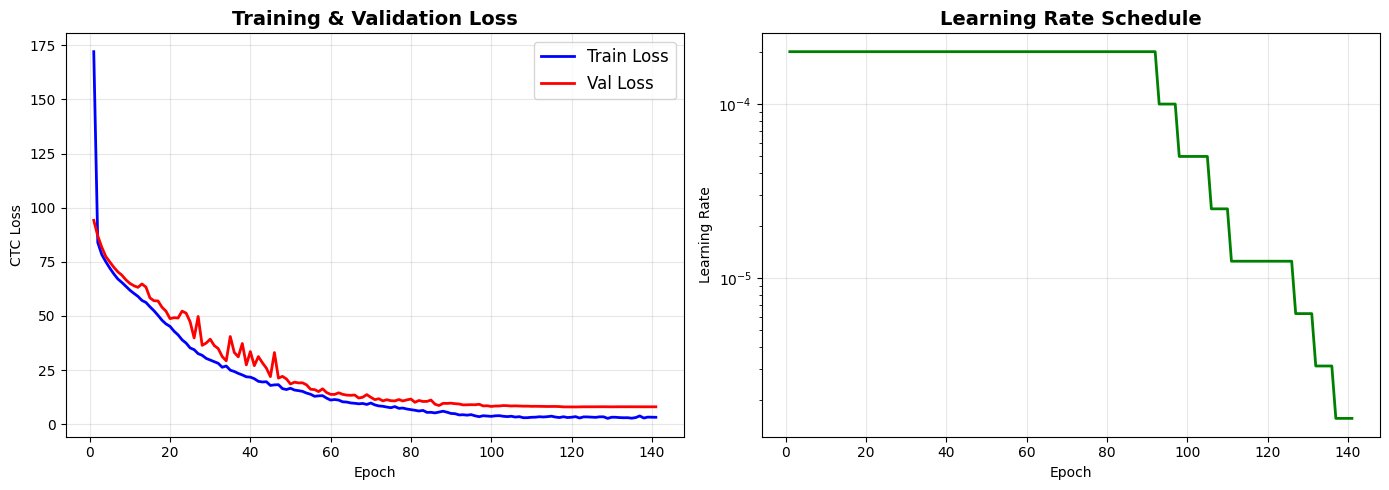

In [ ]:
# Visualisasi training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(monitor.train_losses) + 1)

# Loss curve
axes[0].plot(epochs_range, monitor.train_losses, 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, monitor.val_losses, 'r-', label='Val Loss', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CTC Loss')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Learning rate curve
axes[1].plot(epochs_range, monitor.learning_rates, 'g-', linewidth=2)
axes[1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

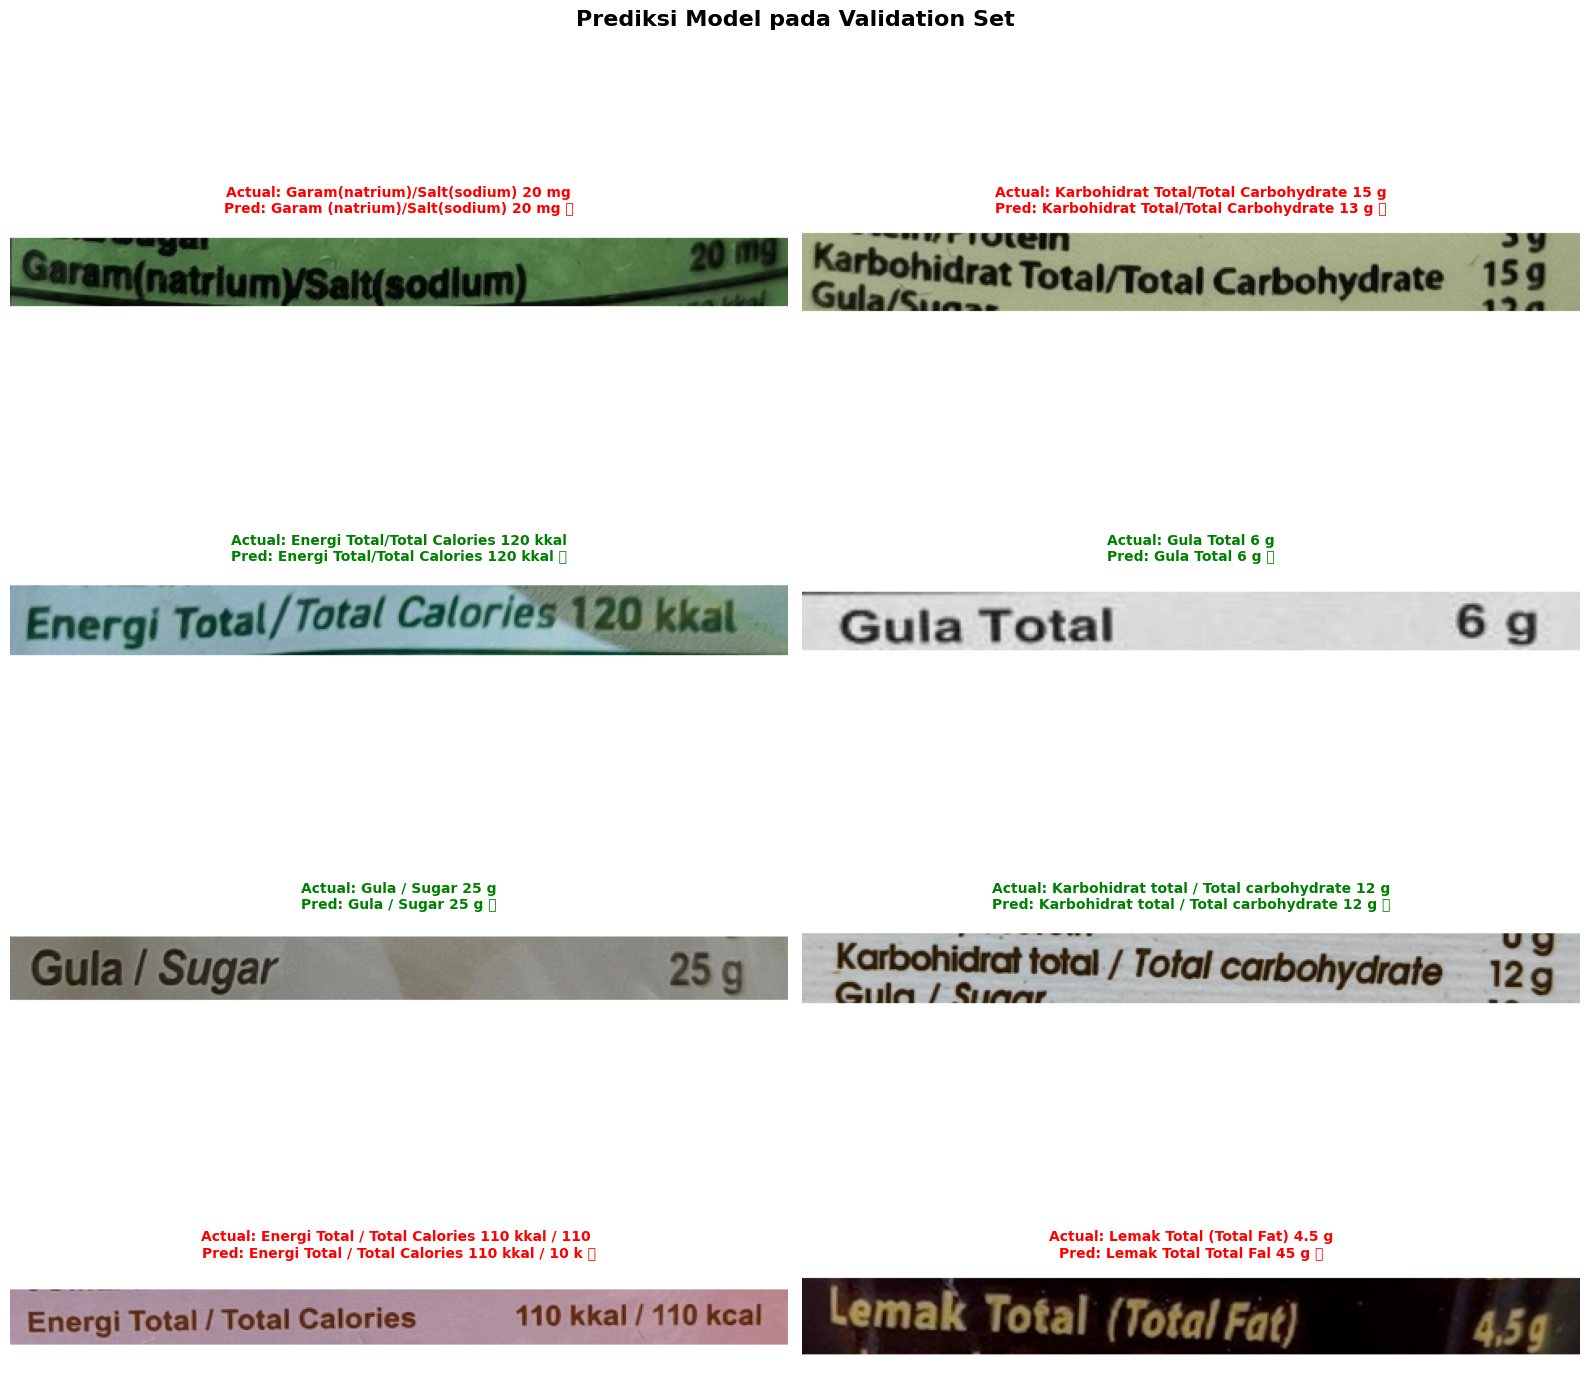

In [ ]:
# Visualisasi prediksi pada gambar
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

# Ambil 8 sampel random dari validation
np.random.seed(42)
sample_indices = np.random.choice(len(X_val), min(8, len(X_val)), replace=False)

for idx, sample_idx in enumerate(sample_indices):
    row, col = idx // 2, idx % 2

    # Tampilkan gambar
    axes[row][col].imshow(X_val[sample_idx])

    # Prediksi
    pred = prediction_model.predict(X_val[sample_idx:sample_idx+1], verbose=0)
    decoded = ctc_decode_predictions(pred, num_to_char)

    actual = val_true_texts[sample_idx]
    predicted = decoded[0]
    is_correct = actual.strip() == predicted.strip()

    color = 'green' if is_correct else 'red'
    status = '✅' if is_correct else '❌'

    axes[row][col].set_title(
        f"Actual: {actual[:45]}\nPred: {predicted[:45]} {status}",
        fontsize=10, color=color, fontweight='bold'
    )
    axes[row][col].axis('off')

plt.suptitle('Prediksi Model pada Validation Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


Analisis per kategori selesai


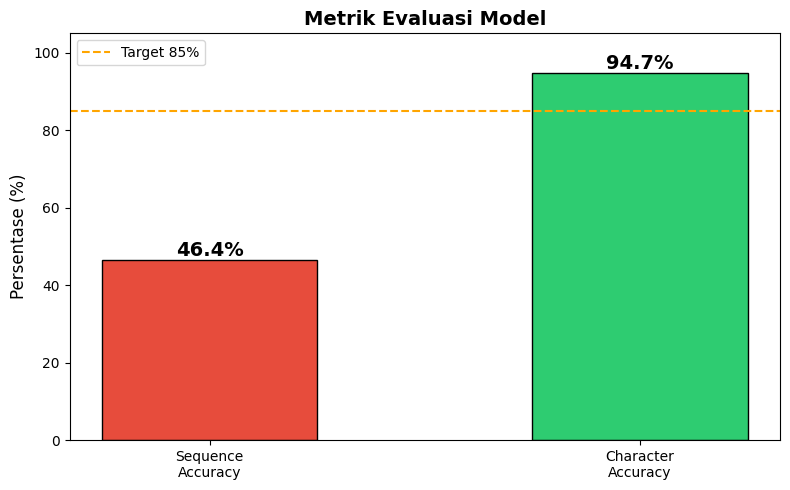

In [ ]:
# Confusion analysis: distribusi error per kategori
# Ambil kategori dari validation data
val_df_subset = df.iloc[valid_indices].iloc[
    [i for i in range(len(df.iloc[valid_indices]))
     if i in [idx for idx in range(len(images))
              if idx >= int(len(images)*0.8)]]
]

# Hitung error rate per kualitas gambar
error_by_quality = {}
for r in val_results:
    # Simple estimation
    is_error = not r['correct']

print("\nAnalisis per kategori selesai")

# Bar chart metrik
fig, ax = plt.subplots(figsize=(8, 5))
metrics_names = ['Sequence\nAccuracy', 'Character\nAccuracy']
metrics_values = [val_metrics['accuracy']*100, (1-val_metrics['CER'])*100]
colors = ['#2ecc71' if v >= 85 else '#e74c3c' for v in metrics_values]

bars = ax.bar(metrics_names, metrics_values, color=colors, width=0.5, edgecolor='black')
ax.set_ylim(0, 105)
ax.set_ylabel('Persentase (%)', fontsize=12)
ax.set_title('Metrik Evaluasi Model', fontsize=14, fontweight='bold')
ax.axhline(y=85, color='orange', linestyle='--', label='Target 85%')
ax.legend()

for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## 10. Inference (Prediksi Gambar Baru)

In [ ]:
# === FUNGSI INFERENCE ===

def predict_text(image_path, model, num_to_char_map,
                 target_h=IMG_HEIGHT, target_w=IMG_WIDTH):
    """
    Prediksi teks dari gambar label nutrisi.

    Fungsi ini nantinya bisa dipanggil setelah YOLOv8
    mendeteksi dan crop area label nutrisi.

    Args:
        image_path: path ke file gambar (atau numpy array)
        model: prediction model CRNN
        num_to_char_map: mapping index -> karakter
        target_h: tinggi target
        target_w: lebar target

    Returns:
        predicted_text: teks hasil prediksi
    """
    # Load dan preprocess gambar
    if isinstance(image_path, str):
        img = preprocess_image(image_path, target_h, target_w)
    elif isinstance(image_path, np.ndarray):
        # Kalau sudah numpy array (misal dari crop YOLOv8)
        if image_path.dtype == np.uint8:
            img = cv2.resize(image_path, (target_w, target_h))
            img = img.astype(np.float32) / 255.0
        else:
            img = cv2.resize(image_path, (target_w, target_h))
    else:
        raise ValueError("Input harus path string atau numpy array")

    # Tambah dimensi batch
    img_batch = np.expand_dims(img, axis=0)

    # Prediksi
    y_pred = model.predict(img_batch, verbose=0)

    # Decode
    decoded = ctc_decode_predictions(y_pred, num_to_char_map)

    return decoded[0]

# === TEST INFERENCE ===
print("=" * 60)
print("TEST INFERENCE")
print("=" * 60)

# Test pada beberapa gambar
test_files = [
    'calories_003.png',
    'calories_049.png',
    'sugar_010.png',
    'sodium_016.png',
    'fat_003.png',
    'carbs_017.png',
]

for fname in test_files:
    img_path = os.path.join(TEST_DIR, fname)
    if os.path.exists(img_path):
        pred_text = predict_text(img_path, prediction_model, num_to_char)

        # Cari ground truth
        gt_row = df[df['file_name'] == fname]
        gt_text = gt_row['text'].values[0] if len(gt_row) > 0 else 'N/A'

        match = '✅' if pred_text.strip() == gt_text.strip() else '❌'
        print(f"File: {fname}")
        print(f"  Ground truth: {gt_text}")
        print(f"  Predicted   : {pred_text} {match}")
        print()

TEST INFERENCE
File: calories_003.png
  Ground truth: Energi Total / Calories 100 kkal
  Predicted   : Energi Total / Calories 100 kkal ✅

File: calories_049.png
  Ground truth: Energi Total 5 kkal
  Predicted   : Energi Total 5 kkal ✅

File: sugar_010.png
  Ground truth: Gula total 17 g
  Predicted   : Gula total 17 g ✅

File: sodium_016.png
  Ground truth: Garam (Natrium)/Salt (Sodium) 25 mg
  Predicted   : Garam (Natrium)/Salt (Sodium) 25 mg ✅

File: fat_003.png
  Ground truth: Lemak Total / Total Fat 4 g
  Predicted   : Lemak Total / Total Fat 4 g ✅

File: carbs_017.png
  Ground truth: Karbohidrat Total 23 g
  Predicted   : Karbohidrat Total 23 g ✅



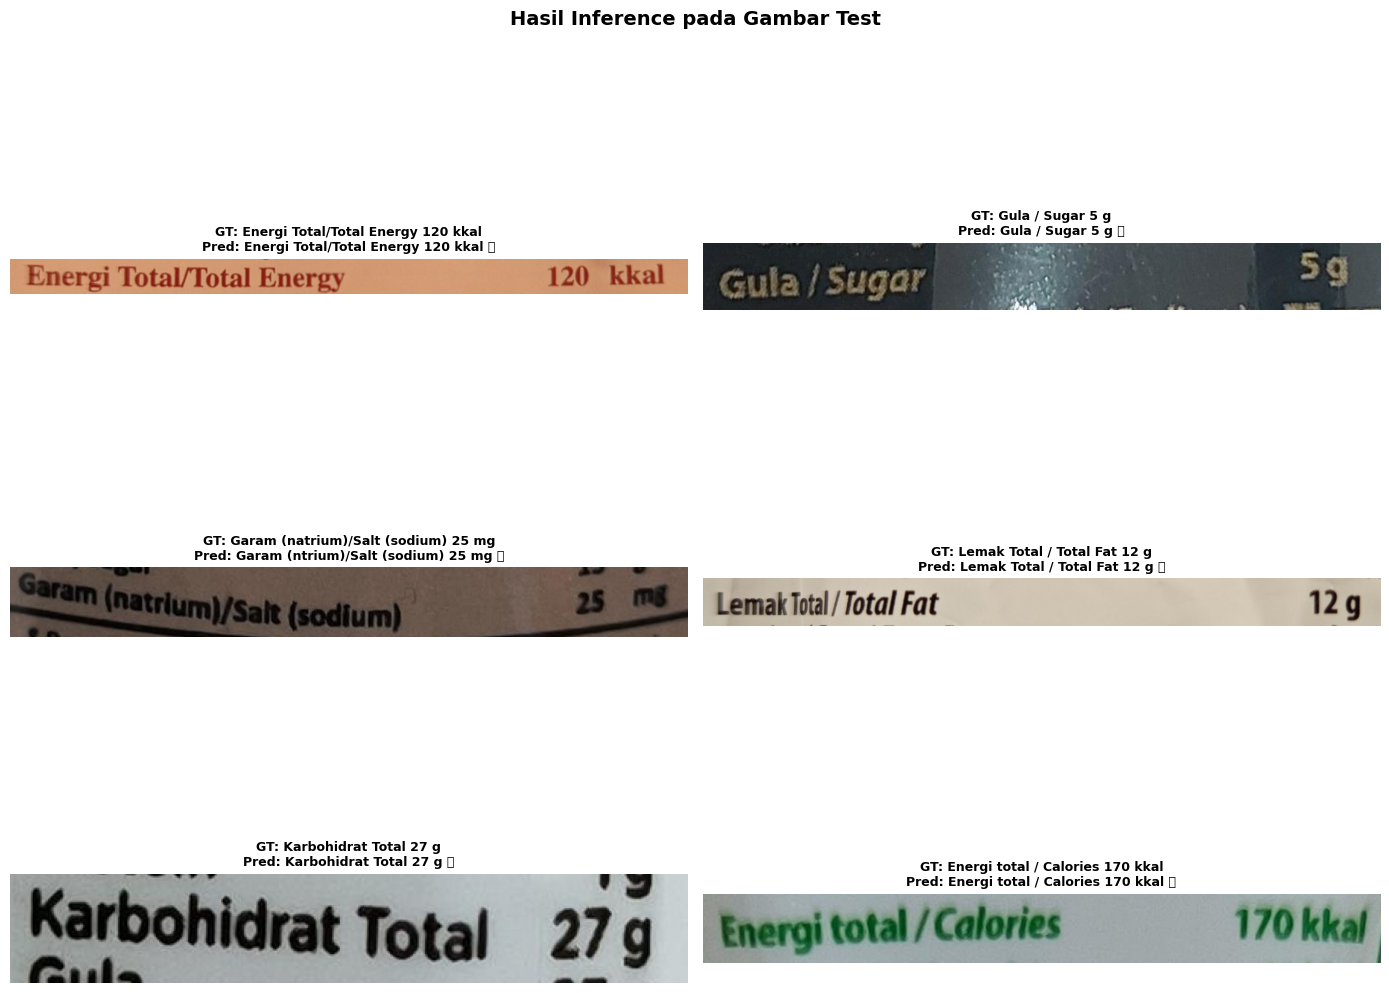

In [ ]:
# Visualisasi inference
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
test_samples = ['calories_005.png', 'sugar_003.png', 'sodium_020.png',
                'fat_007.png', 'carbs_025.png', 'calories_030.png']

for idx, fname in enumerate(test_samples):
    row, col = idx // 2, idx % 2
    img_path = os.path.join(TEST_DIR, fname)

    if os.path.exists(img_path):
        # Tampilkan gambar asli
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)

        # Prediksi
        pred_text = predict_text(img_path, prediction_model, num_to_char)
        gt_row = df[df['file_name'] == fname]
        gt_text = gt_row['text'].values[0] if len(gt_row) > 0 else 'N/A'

        match = '✅' if pred_text.strip() == gt_text.strip() else '❌'
        axes[row][col].set_title(
            f"GT: {gt_text[:40]}\nPred: {pred_text[:40]} {match}",
            fontsize=9, fontweight='bold'
        )
    axes[row][col].axis('off')

plt.suptitle('Hasil Inference pada Gambar Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Export Model

In [ ]:
import json as json_lib

# 1. Save Model path
DRIVE_MODEL_DIR = '/content/drive/MyDrive/Colab_Notebooks/CRNN/saved_model'

# Membuat folder
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)
print(f"Menyimpan ke direktori: {DRIVE_MODEL_DIR}")

# 2. Format .keras
keras_path = os.path.join(DRIVE_MODEL_DIR, "crnn_model.keras")
prediction_model.save(keras_path)
print(f"Model disimpan: {keras_path}")

# 3. Format SavedModel (untuk deployment)
saved_model_path = os.path.join(DRIVE_MODEL_DIR, "crnn_savedmodel")
prediction_model.export(saved_model_path)
print(f"SavedModel diexport: {saved_model_path}")

# 4. Simpan vocabulary/mapping (untuk inference)
vocab_data = {
    'char_to_num': char_to_num,
    'num_to_char': {str(k): v for k, v in num_to_char.items()},
    'vocab': vocab,
    'max_label_length': MAX_LABEL_LENGTH,
    'img_height': IMG_HEIGHT,
    'img_width': IMG_WIDTH,
}

vocab_path = os.path.join(DRIVE_MODEL_DIR, "vocab.json")
with open(vocab_path, 'w', encoding='utf-8') as f:
    json_lib.dump(vocab_data, f, ensure_ascii=False, indent=2)
print(f"Vocabulary disimpan: {vocab_path}")

# Cek isi foldernya
print(f"\nIsi folder di Google Drive:")
for f_name in os.listdir(DRIVE_MODEL_DIR):
    f_path = os.path.join(DRIVE_MODEL_DIR, f_name)
    if os.path.isfile(f_path):
        size_mb = os.path.getsize(f_path) / (1024*1024)
        print(f"   {f_name} ({size_mb:.2f} MB)")
    else:
        print(f"   {f_name}/ (directory)")


Menyimpan ke direktori: /content/drive/MyDrive/Colab_Notebooks/CRNN/saved_model
Model disimpan: /content/drive/MyDrive/Colab_Notebooks/CRNN/saved_model/crnn_model.keras
Saved artifact at '/content/drive/MyDrive/Colab_Notebooks/CRNN/saved_model/crnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 480, 3), dtype=tf.float32, name='input_images')
Output Type:
  TensorSpec(shape=(None, 120, 61), dtype=tf.float32, name=None)
Captures:
  132104365401936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132104365402512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132104365401360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132104365394448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132104365402704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132104365403280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132104365395984: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [ ]:
# === VERIFIKASI: Load ulang model dan test ===
print("\n Verifikasi: Load ulang model...")

loaded_model = tf.keras.models.load_model(
    keras_path,
    custom_objects={'CTCLayer': CTCLayer}
)

# Test prediksi dengan model yang di-load ulang
test_img_path = os.path.join(TEST_DIR, df['file_name'].iloc[0])
pred_original = predict_text(test_img_path, prediction_model, num_to_char)
pred_loaded = predict_text(test_img_path, loaded_model, num_to_char)

print(f"Prediksi model original: '{pred_original}'")
print(f"Prediksi model loaded  : '{pred_loaded}'")
print(f"Hasil sama? {' YA' if pred_original == pred_loaded else ' TIDAK'}")


 Verifikasi: Load ulang model...
Prediksi model original: 'Energi total 10 kkal'
Prediksi model loaded  : 'Energi total 10 kkal'
Hasil sama?  YA
